# 04 - External Data Collection

## Objective
Collect external data (weather, holidays) that influences pool/spa demand independently of marketing spend.

## Data Sources
- **Weather**: Open-Meteo API (free, no key needed) - Montreal, Quebec
- **Holidays**: Quebec statutory holidays

## Output Files
- `external_weather.csv/pkl` - Monthly weather data
- `quotes_spend_weather.csv/pkl` - Merged dataset for modeling

---
## Cell 1: Imports and Setup

In [61]:
import pandas as pd
import numpy as np
import requests
import holidays  # For automatic holiday dates
from datetime import datetime, timedelta
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

# Paths
PROJECT_ROOT = Path('..')
DATA_PROCESSED = PROJECT_ROOT / 'data' / 'processed'

print("✅ Imports complete")
print(f"📁 Data will be saved to: {DATA_PROCESSED.resolve()}")

✅ Imports complete
📁 Data will be saved to: /Users/tuta/Desktop/busa693-clubpiscine/data/processed


---
## Cell 2: Weather Data Configuration

**Location**: Greater Montreal Area (GMA), Quebec  
- Latitude: 45.55  
- Longitude: -73.70  
- This central point represents the broader GMA region

**Coverage**: The Greater Montreal Area includes:
- Montreal Island (downtown, West Island, East End)
- Laval (North Shore)
- Longueuil & South Shore
- Surrounding suburbs

**Rationale**: ~50% of Club Piscine stores are in the GMA. Weather is consistent across the region (all within 50km radius).

**Date Range**:  
- Start: 2023-11-01 (FY2024 start)  
- End: 2025-10-31 (FY2025 end)

In [62]:
# Greater Montreal Area (GMA) - central coordinates
# This point is more central to the GMA, covering:
# - Montreal Island, Laval, South Shore, West Island, surrounding suburbs
LATITUDE = 45.55
LONGITUDE = -73.70
LOCATION_NAME = "Greater Montreal Area"

# Date range (FY2024 start to FY2025 end or today)
START_DATE = "2023-11-01"
END_DATE = min(datetime.now(), datetime(2025, 10, 31)).strftime("%Y-%m-%d")

print(f"📍 Location: {LOCATION_NAME}")
print(f"   Coordinates: ({LATITUDE}, {LONGITUDE})")
print(f"   Coverage: Montreal Island, Laval, South Shore, West Island")
print(f"📅 Date range: {START_DATE} to {END_DATE}")

📍 Location: Greater Montreal Area
   Coordinates: (45.55, -73.7)
   Coverage: Montreal Island, Laval, South Shore, West Island
📅 Date range: 2023-11-01 to 2025-10-31


---
## Cell 3: Fetch Weather Data from Open-Meteo API

**Open-Meteo API** - Free historical weather data (no API key required)

API Endpoint: `https://archive-api.open-meteo.com/v1/archive`

Variables fetched:
- `temperature_2m_max` - Daily maximum temperature
- `temperature_2m_min` - Daily minimum temperature  
- `temperature_2m_mean` - Daily mean temperature
- `precipitation_sum` - Daily total precipitation (mm)
- `sunshine_duration` - Daily sunshine duration (seconds)

In [63]:
def fetch_openmeteo_weather(latitude, longitude, start_date, end_date):
    """
    Fetch historical weather data from Open-Meteo API.
    
    Open-Meteo is a free weather API that provides historical data
    without requiring an API key.
    
    API Documentation: https://open-meteo.com/en/docs/historical-weather-api
    """
    import requests
    
    # API endpoint for historical data
    url = "https://archive-api.open-meteo.com/v1/archive"
    
    # Parameters
    params = {
        "latitude": latitude,
        "longitude": longitude,
        "start_date": start_date,
        "end_date": end_date,
        "daily": [
            "temperature_2m_max",
            "temperature_2m_min",
            "temperature_2m_mean",
            "precipitation_sum",
            "sunshine_duration"
        ],
        "timezone": "America/Montreal"
    }
    
    print(f"🌐 Fetching weather data from Open-Meteo API...")
    print(f"   URL: {url}")
    print(f"   Location: ({latitude}, {longitude})")
    print(f"   Period: {start_date} to {end_date}")
    
    try:
        response = requests.get(url, params=params, timeout=30)
        response.raise_for_status()
        data = response.json()
        
        # Convert to DataFrame
        daily_data = data['daily']
        df = pd.DataFrame({
            'date': pd.to_datetime(daily_data['time']),
            'temp_max': daily_data['temperature_2m_max'],
            'temp_min': daily_data['temperature_2m_min'],
            'temp_mean': daily_data['temperature_2m_mean'],
            'precipitation': daily_data['precipitation_sum'],
            'sunshine_hours': [s / 3600 if s else 0 for s in daily_data['sunshine_duration']]  # Convert seconds to hours
        })
        
        # Handle any None values
        df = df.fillna(0)
        
        print(f"✅ Successfully fetched {len(df)} days of weather data from Open-Meteo API")
        return df
        
    except requests.exceptions.RequestException as e:
        print(f"❌ API request failed: {e}")
        raise

# Fetch weather data from Open-Meteo API
weather_daily = fetch_openmeteo_weather(LATITUDE, LONGITUDE, START_DATE, END_DATE)

print(f"\n📊 Weather data summary:")
print(weather_daily.describe().round(1))
weather_daily.head(10)

🌐 Fetching weather data from Open-Meteo API...
   URL: https://archive-api.open-meteo.com/v1/archive
   Location: (45.55, -73.7)
   Period: 2023-11-01 to 2025-10-31
✅ Successfully fetched 731 days of weather data from Open-Meteo API

📊 Weather data summary:
                      date  temp_max  temp_min  temp_mean  precipitation  \
count                  731     731.0     731.0      731.0          731.0   
mean   2024-10-31 00:00:00      12.5       3.7        8.1            2.9   
min    2023-11-01 00:00:00     -15.3     -27.5      -19.9            0.0   
25%    2024-05-01 12:00:00       2.5      -4.4       -0.3            0.0   
50%    2024-10-31 00:00:00      13.1       4.2        8.6            0.3   
75%    2025-05-01 12:00:00      23.0      13.6       18.6            2.9   
max    2025-10-31 00:00:00      34.0      25.1       28.8          129.0   
std                    NaN      12.0      11.4       11.5            7.3   

       sunshine_hours  
count           731.0  
mean     

,date,temp_max,temp_min,temp_mean,precipitation,sunshine_hours
0,2023-11-01,2.1,-2.7,-0.8,0.5,4.353783
1,2023-11-02,7.5,-1.4,3.1,0.0,5.782164
2,2023-11-03,12.8,4.6,8.5,0.3,4.119283
3,2023-11-04,9.8,0.8,6.6,1.5,8.856811
4,2023-11-05,7.3,-1.0,2.8,0.0,3.192814
5,2023-11-06,6.8,-4.2,1.0,0.6,5.782333
6,2023-11-07,9.8,0.6,6.1,10.4,0.455850
7,2023-11-08,4.1,-1.6,0.4,0.0,8.731328
8,2023-11-09,2.7,-1.3,0.3,2.9,0.000000
9,2023-11-10,7.8,-0.4,3.9,0.2,8.147228


---
## Cell 4: Process Weather Data - Create Derived Features

In [64]:
def add_derived_features(df):
    """
    Add derived weather features relevant to pool/spa demand.
    
    Features:
    - temp_above_20: Flag for pool weather (mean temp > 20°C)
    - temp_above_25: Flag for hot days (mean temp > 25°C)
    - heating_degree_days: Measure of cold (base 18°C)
    - cooling_degree_days: Measure of heat (base 18°C)
    - rolling_temp_7d: 7-day rolling average temperature
    """
    df = df.copy()
    
    # Pool weather indicators
    df['temp_above_20'] = (df['temp_mean'] > 20).astype(int)
    df['temp_above_25'] = (df['temp_mean'] > 25).astype(int)
    df['temp_above_15'] = (df['temp_mean'] > 15).astype(int)  # Mild days
    
    # Degree days (base 18°C - standard for HVAC)
    df['heating_degree_days'] = np.maximum(18 - df['temp_mean'], 0)
    df['cooling_degree_days'] = np.maximum(df['temp_mean'] - 18, 0)
    
    # Rolling averages
    df['rolling_temp_7d'] = df['temp_mean'].rolling(window=7, min_periods=1).mean()
    df['rolling_temp_14d'] = df['temp_mean'].rolling(window=14, min_periods=1).mean()
    
    # Rain day flag
    df['rain_day'] = (df['precipitation'] > 1).astype(int)  # More than 1mm
    
    # Extract year and month for aggregation
    df['year'] = df['date'].dt.year
    df['month_num'] = df['date'].dt.month
    
    print(f"✅ Added {len(df.columns) - 6} derived features")
    return df

weather_daily = add_derived_features(weather_daily)
print(f"\nColumns: {weather_daily.columns.tolist()}")
weather_daily.head()

✅ Added 10 derived features

Columns: ['date', 'temp_max', 'temp_min', 'temp_mean', 'precipitation', 'sunshine_hours', 'temp_above_20', 'temp_above_25', 'temp_above_15', 'heating_degree_days', 'cooling_degree_days', 'rolling_temp_7d', 'rolling_temp_14d', 'rain_day', 'year', 'month_num']


,date,temp_max,temp_min,temp_mean,precipitation,sunshine_hours,temp_above_20,temp_above_25,temp_above_15,heating_degree_days,cooling_degree_days,rolling_temp_7d,rolling_temp_14d,rain_day,year,month_num
0,2023-11-01,2.1,-2.7,-0.8,0.5,4.353783,0,0,0,18.8,0.0,-0.80,-0.80,0,2023,11
1,2023-11-02,7.5,-1.4,3.1,0.0,5.782164,0,0,0,14.9,0.0,1.15,1.15,0,2023,11
2,2023-11-03,12.8,4.6,8.5,0.3,4.119283,0,0,0,9.5,0.0,3.60,3.60,0,2023,11
3,2023-11-04,9.8,0.8,6.6,1.5,8.856811,0,0,0,11.4,0.0,4.35,4.35,1,2023,11
4,2023-11-05,7.3,-1.0,2.8,0.0,3.192814,0,0,0,15.2,0.0,4.04,4.04,0,2023,11


---
## Cell 5: Aggregate Weather Data to Monthly

Match granularity of existing quote/spend data (monthly).

In [65]:
def aggregate_to_monthly(df):
    """
    Aggregate daily weather data to monthly level.
    
    Aggregations:
    - Temperature: mean of daily values
    - Precipitation: sum
    - Sunshine: sum
    - Indicator days: count/sum
    """
    monthly = df.groupby(['year', 'month_num']).agg({
        # Temperature averages
        'temp_max': 'mean',
        'temp_min': 'mean',
        'temp_mean': 'mean',
        
        # Totals
        'precipitation': 'sum',
        'sunshine_hours': 'sum',
        
        # Count of indicator days
        'temp_above_15': 'sum',
        'temp_above_20': 'sum',
        'temp_above_25': 'sum',
        'rain_day': 'sum',
        
        # Degree days (sum)
        'heating_degree_days': 'sum',
        'cooling_degree_days': 'sum',
        
        # Last day of month's rolling average
        'rolling_temp_7d': 'last'
    }).reset_index()
    
    # Rename columns for clarity
    monthly.columns = [
        'year', 'month_num',
        'avg_temp_max', 'avg_temp_min', 'avg_temp_mean',
        'total_precipitation', 'total_sunshine_hours',
        'days_above_15', 'days_above_20', 'days_above_25',
        'rain_days',
        'heating_degree_days', 'cooling_degree_days',
        'rolling_temp_7d_eom'
    ]
    
    # Add French month names to match existing data
    month_names_fr = {
        1: 'Janvier', 2: 'Février', 3: 'Mars', 4: 'Avril',
        5: 'Mai', 6: 'Juin', 7: 'Juillet', 8: 'Août',
        9: 'Septembre', 10: 'Octobre', 11: 'Novembre', 12: 'Décembre'
    }
    monthly['month'] = monthly['month_num'].map(month_names_fr)
    
    # Round numeric columns
    numeric_cols = monthly.select_dtypes(include=[np.number]).columns
    monthly[numeric_cols] = monthly[numeric_cols].round(2)
    
    print(f"✅ Aggregated to {len(monthly)} months of data")
    return monthly

weather_monthly = aggregate_to_monthly(weather_daily)
print(f"\nDate range: {weather_monthly['year'].min()}-{weather_monthly['month_num'].min():02d} to {weather_monthly['year'].max()}-{weather_monthly['month_num'].max():02d}")
weather_monthly

✅ Aggregated to 24 months of data

Date range: 2023-01 to 2025-12


,year,month_num,avg_temp_max,avg_temp_min,avg_temp_mean,total_precipitation,total_sunshine_hours,days_above_15,days_above_20,days_above_25,rain_days,heating_degree_days,cooling_degree_days,rolling_temp_7d_eom,month
0,2023,11,5.10,-2.32,1.28,55.4,165.85,0,0,0,9,501.5,0.0,-1.37,Novembre
1,2023,12,1.04,-5.24,-1.90,128.4,98.42,0,0,0,12,617.0,0.0,0.33,Décembre
2,2024,1,-2.78,-10.27,-6.35,77.9,125.93,0,0,0,11,754.7,0.0,-3.31,Janvier
3,2024,2,0.19,-10.22,-4.57,25.9,203.05,0,0,0,6,654.6,0.0,-2.60,Février
4,2024,3,6.42,-3.28,1.28,66.8,222.40,0,0,0,11,518.4,0.0,3.97,Mars
5,2024,4,11.98,1.46,6.66,135.5,232.08,0,0,0,15,340.2,0.0,7.31,Avril
6,2024,5,20.76,10.55,15.69,72.2,330.82,18,4,0,14,92.6,21.0,16.96,Mai
7,2024,6,24.76,14.85,19.94,154.2,300.92,29,15,3,15,17.1,75.3,19.40,Juin
8,2024,7,26.92,17.87,22.35,145.2,362.76,31,28,1,15,0.0,135.0,22.77,Juillet
9,2024,8,24.67,16.40,20.38,226.8,290.52,30,16,3,16,10.2,84.1,19.86,Août


---
## Cell 6: Quebec Holidays (Automatic)

Using the **`holidays`** Python library to automatically get Quebec statutory holidays.

**Advantages:**
- No manual updates needed - library is maintained
- Handles variable dates (Easter, Victoria Day, Labour Day, Thanksgiving)
- Includes all Quebec-specific holidays (St-Jean-Baptiste, National Patriots' Day)

**Library:** `pip install holidays`  
**Documentation:** https://github.com/vacanza/python-holidays

In [66]:
def get_quebec_holidays_auto(years):
    """
    Automatically get Quebec statutory holidays using the 'holidays' library.
    
    This replaces manual holiday definitions - no updates needed!
    The library handles variable dates (Easter, Victoria Day, etc.) automatically.
    """
    # Get Quebec holidays from the library
    qc_holidays = holidays.Canada(prov='QC', years=years)
    
    # Convert to DataFrame
    holidays_list = []
    for date, name in sorted(qc_holidays.items()):
        # Determine season impact based on holiday
        if 'Jean Baptiste' in name or 'Canada Day' in name:
            season_impact = 'peak'
        elif 'Patriots' in name or 'Victoria' in name:
            season_impact = 'pool_opening'
        elif 'Labour' in name:
            season_impact = 'pool_closing'
        elif 'Thanksgiving' in name:
            season_impact = 'end_season'
        elif 'Easter' in name or 'Good Friday' in name:
            season_impact = 'spring_start'
        else:
            season_impact = 'low'
        
        holidays_list.append({
            'date': date,
            'holiday': name,
            'season_impact': season_impact,
            'year': date.year,
            'month_num': date.month
        })
    
    df = pd.DataFrame(holidays_list)
    df['date'] = pd.to_datetime(df['date'])
    
    return df

# Get holidays automatically for 2023-2025
holidays_df = get_quebec_holidays_auto([2023, 2024, 2025])

print(f"✅ Automatically fetched {len(holidays_df)} Quebec holidays")
print(f"\nHolidays by year:")
print(holidays_df.groupby('year').size())
print(f"\nAll holidays:")
holidays_df.sort_values('date')

✅ Automatically fetched 25 Quebec holidays

Holidays by year:
year
2023    9
2024    8
2025    8
dtype: int64

All holidays:


,date,holiday,season_impact,year,month_num
0,2023-01-01,New Year's Day,low,2023,1
1,2023-01-02,New Year's Day (observed),low,2023,1
2,2023-04-07,Good Friday,spring_start,2023,4
3,2023-05-22,National Patriots' Day,pool_opening,2023,5
4,2023-06-24,Saint Jean Baptiste Day,peak,2023,6
5,2023-07-01,Canada Day,peak,2023,7
6,2023-09-04,Labour Day,pool_closing,2023,9
7,2023-10-09,Thanksgiving Day,end_season,2023,10
8,2023-12-25,Christmas Day,low,2023,12
9,2024-01-01,New Year's Day,low,2024,1


In [67]:
# Aggregate holidays to monthly level (count of holidays and flags)
def aggregate_holidays_monthly(holidays_df):
    """
    Aggregate holidays to monthly level with relevant flags.
    """
    # Count holidays per month
    monthly_counts = holidays_df.groupby(['year', 'month_num']).size().reset_index(name='n_holidays')
    
    # Create season impact flags
    impact_flags = holidays_df.pivot_table(
        index=['year', 'month_num'],
        columns='season_impact',
        aggfunc='size',
        fill_value=0
    ).reset_index()
    
    # Flatten column names
    impact_flags.columns = ['year', 'month_num'] + [f'holiday_{c}' for c in impact_flags.columns[2:]]
    
    # Merge
    monthly_holidays = monthly_counts.merge(impact_flags, on=['year', 'month_num'], how='outer')
    
    # Convert flags to binary
    flag_cols = [c for c in monthly_holidays.columns if c.startswith('holiday_')]
    monthly_holidays[flag_cols] = (monthly_holidays[flag_cols] > 0).astype(int)
    
    return monthly_holidays

holidays_monthly = aggregate_holidays_monthly(holidays_df)
print(f"✅ Aggregated holidays to {len(holidays_monthly)} month-records")
holidays_monthly

✅ Aggregated holidays to 24 month-records


,year,month_num,n_holidays,holiday_end_season,holiday_low,holiday_peak,holiday_pool_closing,holiday_pool_opening,holiday_spring_start
0,2023,1,2,0,1,0,0,0,0
1,2023,4,1,0,0,0,0,0,1
2,2023,5,1,0,0,0,0,1,0
3,2023,6,1,0,0,1,0,0,0
4,2023,7,1,0,0,1,0,0,0
5,2023,9,1,0,0,0,1,0,0
6,2023,10,1,1,0,0,0,0,0
7,2023,12,1,0,1,0,0,0,0
8,2024,1,1,0,1,0,0,0,0
9,2024,3,1,0,0,0,0,0,1


---
## Cell 7: Load Existing Data and Merge

In [68]:
# Load existing merged quotes + spend data
quotes_spend = pd.read_pickle(DATA_PROCESSED / 'quotes_spend_merged.pkl')
print(f"📂 Loaded quotes_spend_merged.pkl: {quotes_spend.shape}")
print(f"   Columns: {quotes_spend.columns.tolist()[:10]}...")
print(f"   Date range: {quotes_spend['year'].min()}-{quotes_spend['year'].max()}")

📂 Loaded quotes_spend_merged.pkl: (19, 27)
   Columns: ['year', 'month', 'month_num', 'piscines_hors_terre', 'piscines_creusees', 'spas', 'autres_produits', 'services', 'autre', 'total_main_quotes']...
   Date range: 2024-2025


In [69]:
# Merge weather data with quotes_spend
def merge_external_data(quotes_spend, weather_monthly, holidays_monthly):
    """
    Merge external data (weather, holidays) with existing quotes+spend data.
    """
    # Ensure year is int
    quotes_spend = quotes_spend.copy()
    quotes_spend['year'] = quotes_spend['year'].astype(int)
    weather_monthly['year'] = weather_monthly['year'].astype(int)
    holidays_monthly['year'] = holidays_monthly['year'].astype(int)
    
    # Merge weather
    merged = quotes_spend.merge(
        weather_monthly,
        on=['year', 'month_num', 'month'],
        how='left'
    )
    print(f"✅ Merged weather: {merged.shape[0]} rows, {merged.shape[1]} cols")
    
    # Merge holidays
    merged = merged.merge(
        holidays_monthly,
        on=['year', 'month_num'],
        how='left'
    )
    
    # Fill missing holiday counts with 0
    holiday_cols = [c for c in merged.columns if 'holiday' in c.lower() or 'n_holidays' in c]
    merged[holiday_cols] = merged[holiday_cols].fillna(0).astype(int)
    
    print(f"✅ Merged holidays: {merged.shape[0]} rows, {merged.shape[1]} cols")
    return merged

quotes_spend_weather = merge_external_data(quotes_spend, weather_monthly, holidays_monthly)
print(f"\n📊 Final dataset shape: {quotes_spend_weather.shape}")
quotes_spend_weather.head()

✅ Merged weather: 19 rows, 39 cols
✅ Merged holidays: 19 rows, 46 cols

📊 Final dataset shape: (19, 46)


,year,month,month_num,piscines_hors_terre,piscines_creusees,spas,autres_produits,services,autre,total_main_quotes,total_all_quotes,date,spend_bannières_web___premium,spend_circulaire_digital,spend_circulaire_digitale,spend_contenu_de_marque,spend_google_ads,spend_google_shopping,"spend_lapresse_(lp+,_preroll,_display)",spend_panneaux,spend_panneaux_et_affichages_numériques,spend_preroll___premium,spend_radio,spend_radio_numérique,spend_social_media,spend_television,spend_total,avg_temp_max,avg_temp_min,avg_temp_mean,total_precipitation,total_sunshine_hours,days_above_15,days_above_20,days_above_25,rain_days,heating_degree_days,cooling_degree_days,rolling_temp_7d_eom,n_holidays,holiday_end_season,holiday_low,holiday_peak,holiday_pool_closing,holiday_pool_opening,holiday_spring_start
0,2024,Janvier,1,126.0,126.0,14.0,45.0,20.0,286.0,266.0,617.0,2024-01-01,11945.945946,14702.702703,0.0,0.0,36756.756757,7000.000000,0.0,0.000000,0.0,0.000000,0.000000,0.0,25729.729730,0.000000,96135.135135,-2.78,-10.27,-6.35,77.9,125.93,0,0,0,11,754.7,0.0,-3.31,1,0,1,0,0,0,0
1,2024,Février,2,240.0,229.0,26.0,74.0,33.0,184.0,495.0,786.0,2024-02-01,11945.945946,0.000000,0.0,0.0,45945.945946,7000.000000,0.0,0.000000,0.0,13783.783784,0.000000,0.0,27567.567568,174594.594595,280837.837838,0.19,-10.22,-4.57,25.9,203.05,0,0,0,6,654.6,0.0,-2.60,0,0,0,0,0,0,0
2,2024,Mars,3,445.0,388.0,46.0,146.0,120.0,219.0,879.0,1364.0,2024-03-01,13783.783784,0.000000,0.0,0.0,45945.945946,9740.540541,0.0,0.000000,0.0,18378.378378,66838.707027,0.0,27567.567568,220540.540541,402795.463784,6.42,-3.28,1.28,66.8,222.40,0,0,0,11,518.4,0.0,3.97,1,0,0,0,0,0,1
3,2024,Avril,4,553.0,486.0,71.0,313.0,252.0,261.0,1110.0,1936.0,2024-04-01,18378.378378,39972.972973,0.0,0.0,59729.729730,19481.081081,0.0,0.000000,0.0,32162.162162,153026.648649,0.0,36756.756757,349189.189189,708696.918919,11.98,1.46,6.66,135.5,232.08,0,0,0,15,340.2,0.0,7.31,0,0,0,0,0,0,0
4,2024,Mai,5,805.0,324.0,55.0,304.0,309.0,478.0,1184.0,2275.0,2024-05-01,18378.378378,39972.972973,0.0,0.0,59729.729730,19481.081081,0.0,13783.783784,0.0,32162.162162,129940.648649,0.0,41351.351351,261891.891892,616692.000000,20.76,10.55,15.69,72.2,330.82,18,4,0,14,92.6,21.0,16.96,1,0,0,0,0,1,0


In [70]:
# Check for any missing values after merge
print("Missing values in merged dataset:")
missing = quotes_spend_weather.isnull().sum()
missing_cols = missing[missing > 0]
if len(missing_cols) > 0:
    print(missing_cols)
else:
    print("✅ No missing values!")

Missing values in merged dataset:
✅ No missing values!


---
## Cell 8: Visualizations

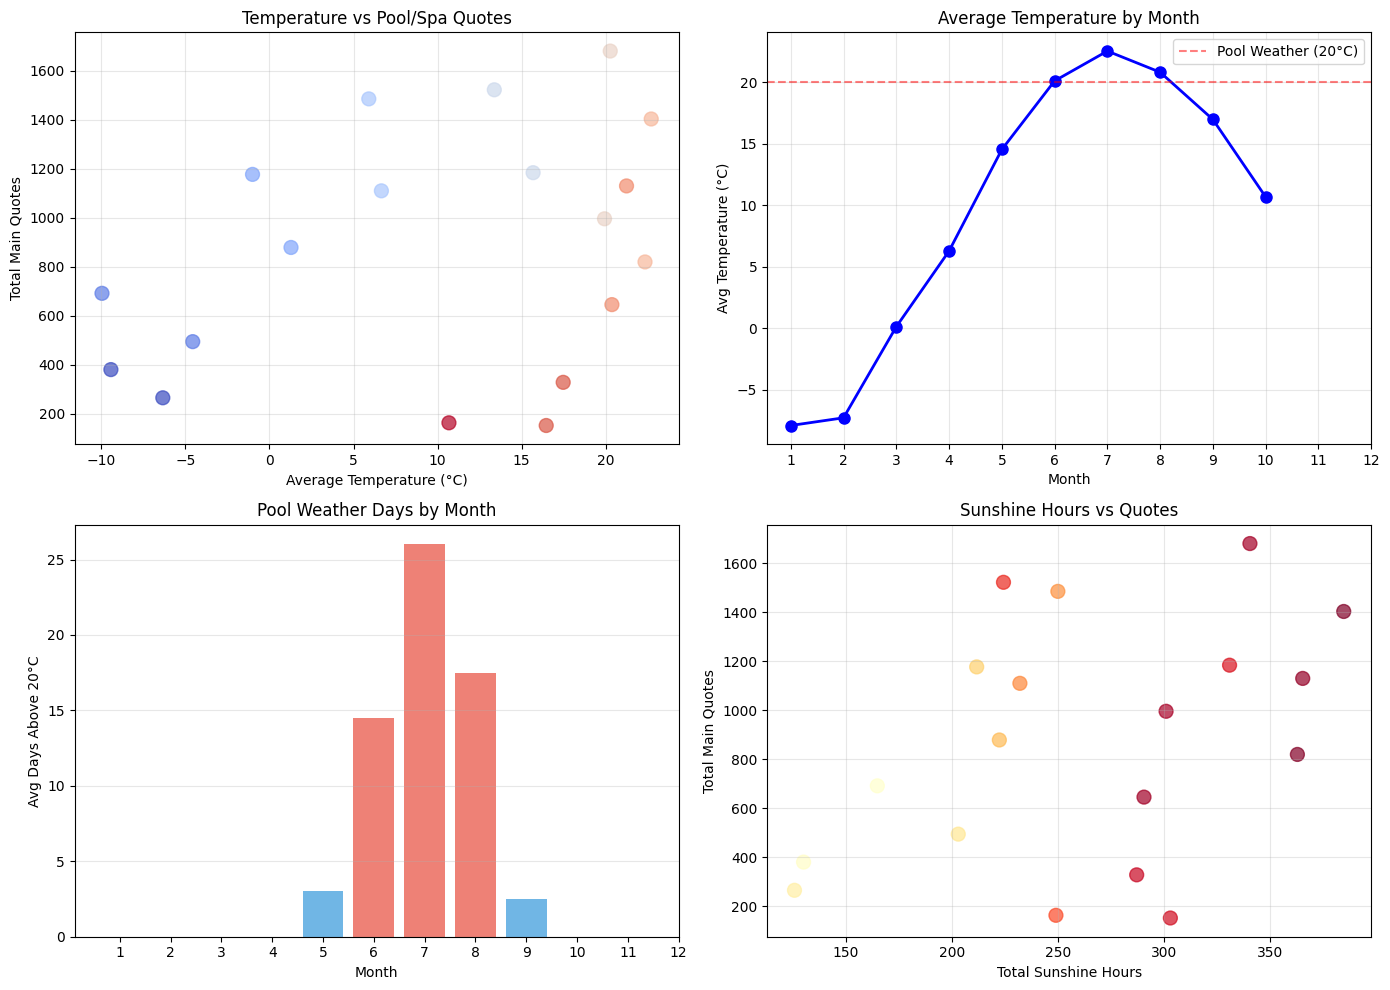


📊 Saved weather analysis plot


In [71]:
# Create reports directory if it doesn't exist
reports_dir = DATA_PROCESSED.parent / 'reports'
reports_dir.mkdir(exist_ok=True)

# Plot 1: Temperature vs Total Quotes
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Scatter: Temperature vs Quotes
ax1 = axes[0, 0]
ax1.scatter(quotes_spend_weather['avg_temp_mean'], 
            quotes_spend_weather['total_main_quotes'],
            c=quotes_spend_weather['month_num'],
            cmap='coolwarm', s=100, alpha=0.7)
ax1.set_xlabel('Average Temperature (°C)')
ax1.set_ylabel('Total Main Quotes')
ax1.set_title('Temperature vs Pool/Spa Quotes')
ax1.grid(True, alpha=0.3)

# Line: Monthly temperature trend
ax2 = axes[0, 1]
temp_by_month = quotes_spend_weather.groupby('month_num')['avg_temp_mean'].mean()
ax2.plot(temp_by_month.index, temp_by_month.values, 'b-o', linewidth=2, markersize=8)
ax2.set_xlabel('Month')
ax2.set_ylabel('Avg Temperature (°C)')
ax2.set_title('Average Temperature by Month')
ax2.set_xticks(range(1, 13))
ax2.grid(True, alpha=0.3)
ax2.axhline(y=20, color='r', linestyle='--', alpha=0.5, label='Pool Weather (20°C)')
ax2.legend()

# Bar: Days above 20°C by month
ax3 = axes[1, 0]
warm_days = quotes_spend_weather.groupby('month_num')['days_above_20'].mean()
colors = ['#3498db' if x < 10 else '#e74c3c' for x in warm_days.values]
ax3.bar(warm_days.index, warm_days.values, color=colors, alpha=0.7)
ax3.set_xlabel('Month')
ax3.set_ylabel('Avg Days Above 20°C')
ax3.set_title('Pool Weather Days by Month')
ax3.set_xticks(range(1, 13))
ax3.grid(True, alpha=0.3, axis='y')

# Scatter: Sunshine vs Quotes
ax4 = axes[1, 1]
ax4.scatter(quotes_spend_weather['total_sunshine_hours'], 
            quotes_spend_weather['total_main_quotes'],
            c=quotes_spend_weather['avg_temp_mean'],
            cmap='YlOrRd', s=100, alpha=0.7)
ax4.set_xlabel('Total Sunshine Hours')
ax4.set_ylabel('Total Main Quotes')
ax4.set_title('Sunshine Hours vs Quotes')
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(reports_dir / 'weather_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n📊 Saved weather analysis plot")

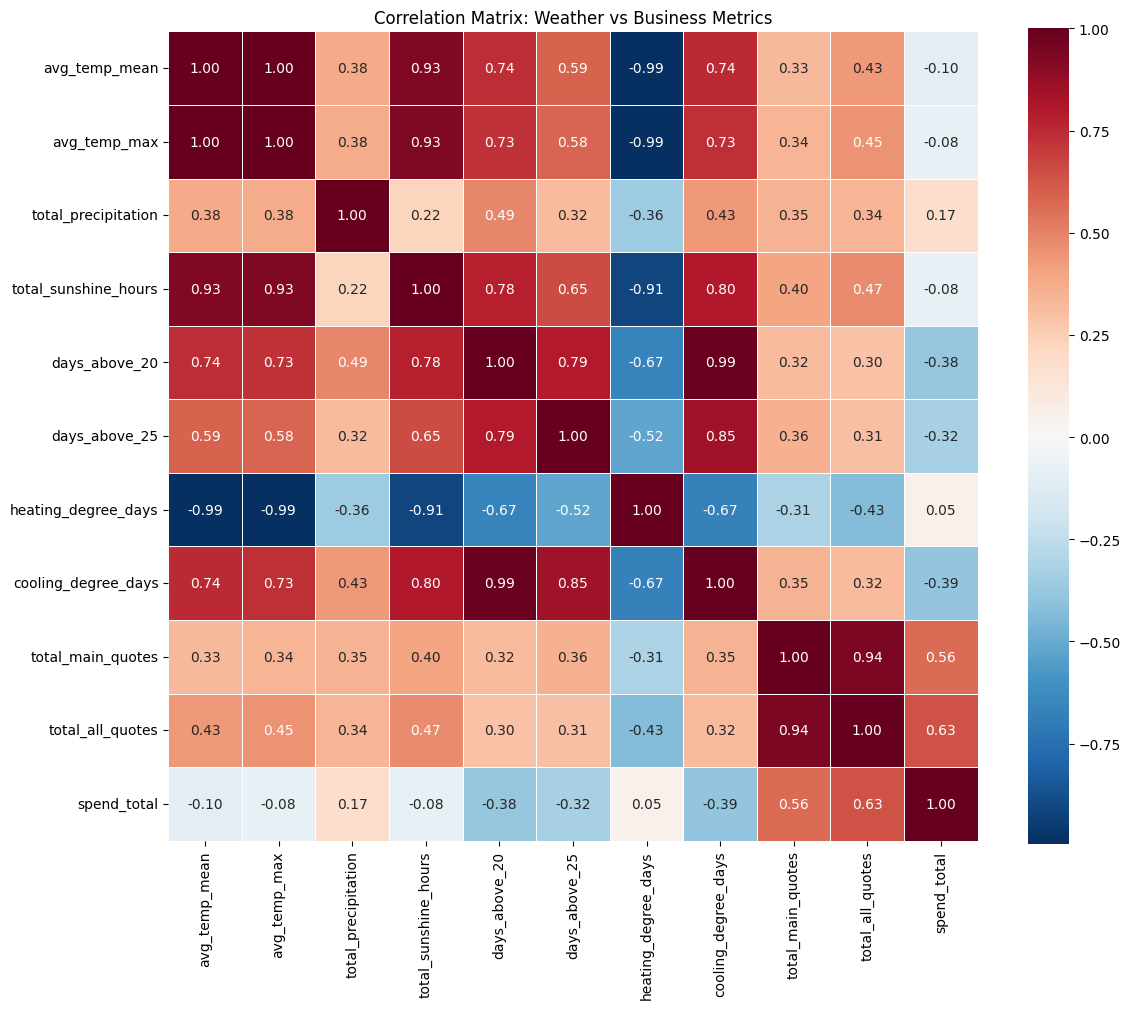


📈 Key correlations with total_main_quotes:
   total_all_quotes: 0.945
   spend_total: 0.565
   total_sunshine_hours: 0.400
   days_above_25: 0.359
   total_precipitation: 0.353
   cooling_degree_days: 0.346
   avg_temp_max: 0.341
   avg_temp_mean: 0.328
   days_above_20: 0.317
   heating_degree_days: -0.311


In [72]:
# Correlation matrix including weather variables
weather_cols = ['avg_temp_mean', 'avg_temp_max', 'total_precipitation', 
                'total_sunshine_hours', 'days_above_20', 'days_above_25',
                'heating_degree_days', 'cooling_degree_days']
target_cols = ['total_main_quotes', 'total_all_quotes', 'spend_total']

corr_cols = weather_cols + target_cols
available_cols = [c for c in corr_cols if c in quotes_spend_weather.columns]

corr_matrix = quotes_spend_weather[available_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0, 
            fmt='.2f', square=True, linewidths=0.5)
plt.title('Correlation Matrix: Weather vs Business Metrics')
plt.tight_layout()
plt.savefig(reports_dir / 'weather_correlations.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📈 Key correlations with total_main_quotes:")
if 'total_main_quotes' in corr_matrix.columns:
    correlations = corr_matrix['total_main_quotes'].drop('total_main_quotes').sort_values(ascending=False)
    for var, corr in correlations.items():
        print(f"   {var}: {corr:.3f}")

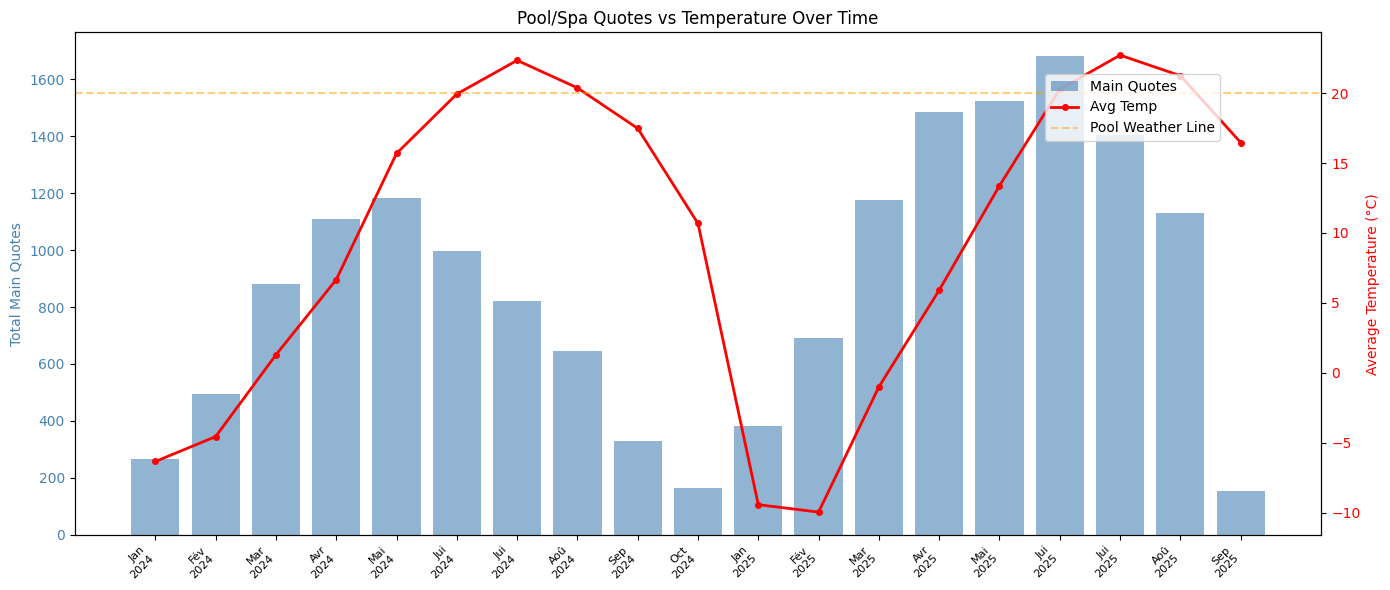

In [73]:
# Overlay: Weather on seasonality chart
fig, ax1 = plt.subplots(figsize=(14, 6))

# Create month order for proper sorting
month_order = ['Janvier', 'Février', 'Mars', 'Avril', 'Mai', 'Juin',
               'Juillet', 'Août', 'Septembre', 'Octobre', 'Novembre', 'Décembre']
plot_df = quotes_spend_weather.copy()
plot_df['month_cat'] = pd.Categorical(
    plot_df['month'], 
    categories=month_order, 
    ordered=True
)
plot_data = plot_df.sort_values(['year', 'month_cat'])

# Bar chart for quotes
x = range(len(plot_data))
ax1.bar(x, plot_data['total_main_quotes'], alpha=0.6, color='steelblue', label='Main Quotes')
ax1.set_ylabel('Total Main Quotes', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')

# Line for temperature
ax2 = ax1.twinx()
ax2.plot(x, plot_data['avg_temp_mean'], 'r-o', linewidth=2, markersize=4, label='Avg Temp')
ax2.set_ylabel('Average Temperature (°C)', color='red')
ax2.tick_params(axis='y', labelcolor='red')
ax2.axhline(y=20, color='orange', linestyle='--', alpha=0.5, label='Pool Weather Line')

# X-axis labels
labels = [f"{row['month'][:3]}\n{row['year']}" for _, row in plot_data.iterrows()]
ax1.set_xticks(x)
ax1.set_xticklabels(labels, rotation=45, ha='right', fontsize=8)

plt.title('Pool/Spa Quotes vs Temperature Over Time')
fig.legend(loc='upper right', bbox_to_anchor=(0.88, 0.88))
plt.tight_layout()
plt.savefig(reports_dir / 'quotes_vs_temperature.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Cell 9: Save Final Datasets

In [74]:
# Save weather data (standalone)
weather_monthly.to_csv(DATA_PROCESSED / 'external_weather.csv', index=False)
weather_monthly.to_pickle(DATA_PROCESSED / 'external_weather.pkl')
print(f"✅ Saved: external_weather.csv ({weather_monthly.shape})")
print(f"✅ Saved: external_weather.pkl")

# Save merged dataset (without temporary columns)
output_df = quotes_spend_weather.copy()
if 'month_cat' in output_df.columns:
    output_df = output_df.drop(columns=['month_cat'])

output_df.to_csv(DATA_PROCESSED / 'quotes_spend_weather.csv', index=False)
output_df.to_pickle(DATA_PROCESSED / 'quotes_spend_weather.pkl')
print(f"✅ Saved: quotes_spend_weather.csv ({output_df.shape})")
print(f"✅ Saved: quotes_spend_weather.pkl")

✅ Saved: external_weather.csv ((24, 15))
✅ Saved: external_weather.pkl
✅ Saved: quotes_spend_weather.csv ((19, 46))
✅ Saved: quotes_spend_weather.pkl


In [75]:
# Final summary
print("="*60)
print("EXTERNAL DATA COLLECTION COMPLETE")
print("="*60)
print(f"\n📊 Weather Data:")
print(f"   - Source: Open-Meteo API (real historical data)")
print(f"   - Location: {LOCATION_NAME} ({LATITUDE}, {LONGITUDE})")
print(f"   - Coverage: Montreal Island, Laval, South Shore, West Island")
print(f"   - Period: {START_DATE} to {END_DATE}")
print(f"   - Daily records: {len(weather_daily)}")
print(f"   - Monthly records: {len(weather_monthly)}")

print(f"\n🎉 Holidays Data:")
print(f"   - Quebec statutory holidays")
print(f"   - Records: {len(holidays_df)}")

print(f"\n📁 Output Files:")
print(f"   - {DATA_PROCESSED / 'external_weather.csv'}")
print(f"   - {DATA_PROCESSED / 'external_weather.pkl'}")
print(f"   - {DATA_PROCESSED / 'quotes_spend_weather.csv'}")
print(f"   - {DATA_PROCESSED / 'quotes_spend_weather.pkl'}")

print(f"\n📈 Final Dataset Columns ({len(output_df.columns)}):")
for i, col in enumerate(output_df.columns):
    print(f"   {i+1:2d}. {col}")

EXTERNAL DATA COLLECTION COMPLETE

📊 Weather Data:
   - Source: Open-Meteo API (real historical data)
   - Location: Greater Montreal Area (45.55, -73.7)
   - Coverage: Montreal Island, Laval, South Shore, West Island
   - Period: 2023-11-01 to 2025-10-31
   - Daily records: 731
   - Monthly records: 24

🎉 Holidays Data:
   - Quebec statutory holidays
   - Records: 25

📁 Output Files:
   - ../data/processed/external_weather.csv
   - ../data/processed/external_weather.pkl
   - ../data/processed/quotes_spend_weather.csv
   - ../data/processed/quotes_spend_weather.pkl

📈 Final Dataset Columns (46):
    1. year
    2. month
    3. month_num
    4. piscines_hors_terre
    5. piscines_creusees
    6. spas
    7. autres_produits
    8. services
    9. autre
   10. total_main_quotes
   11. total_all_quotes
   12. date
   13. spend_bannières_web___premium
   14. spend_circulaire_digital
   15. spend_circulaire_digitale
   16. spend_contenu_de_marque
   17. spend_google_ads
   18. spend_google_s

---
## Next Steps

The merged dataset `quotes_spend_weather.pkl` is now ready for:

1. **05_feature_engineering.ipynb** - Add adstock, saturation, and lag features
2. **06_model_building.ipynb** - Build the MMM model

Key weather variables for modeling:
- `avg_temp_mean` - Primary temperature driver
- `days_above_20` - Pool weather indicator  
- `cooling_degree_days` - Heat measure
- `total_sunshine_hours` - Outdoor activity driver

**Data Sources:**
- Weather: Open-Meteo API (real historical data for Montreal)
- Holidays: Quebec statutory holidays (python-holidays package)


NOTEBOOK 05 (Feature Engineering) will load quotes_spend_weather.pkl and:
   1. Apply ADSTOCK to spend columns (carryover effect of ads)
   2. Apply SATURATION curves (diminishing returns)
   3. Create LAG features (delayed response)
   
NOTEBOOK 06 (Model Building) will use the transformed data to:
   1. Build regression model: quotes = f(spend, weather, holidays)
   2. Calculate ROI per channel
   3. Optimize budget allocation